In [ ]:
""" GEÇMİŞ VERİLERİ TAŞIMA """
import numpy as np
import tensorflow as tf

print("Veriler eski notebook'tan çekiliyor...")

# Kaydettiğimiz sıkıştırılmış paketi açıyoruz
data = np.load('/kaggle/input/datasets/denizbyat/aaaaaa/lstm_hazirlik_verisi.npz')

X_scaled = data['X']      # Ölçeklenmiş özellikler
y_erken_uyari = data['y']   # Tehlike (1) ve Güvenli (0) etiketleri
gecerli_indeksler = data['valid_idx']   # Geçerli indeksler (NaN olmayan satırların indeksleri)

# Belleği rahatlatmak için paketi kapat
data.close()

print(f"Veri başarıyla yüklendi! X boyutu: {X_scaled.shape}")
print(f"Tehlike (1) Etiketi Taşıyan Satır Sayısı: {np.sum(y_erken_uyari)}")
print("Sistem LSTM Modeli inşası için hazır.")

Önceki notebookdaki verileri taşıyarak kaggle da da yeni notebook üzerinde çalışacağız. Sonrasında 06.dosyada bulduğumuz 167 kesin kriz anını birer "Çarpışma Noktası" olarak kabul edip. Sonra zamanı 5 dakika (300 adım) geriye sardık. Yani şunu demiş olduk kısaca "bu çarpışma anından önceki 5 dakika boyunca makinenin ritmi değişiyor. Git ve o 5 dakikalık süreyi Tehlike (Y=1) olarak işaretle." Geri kalan tüm normal zamanları ise Güvenli (Y=0) olarak bırak" Bu etiketlemelerin olduğu veri setinide (.npz uzantılı olan) diğer dosyaya geçtiğimiz için veri setini alıp yeni notebook için upload ettik. Şimdi elimizde bu bahsettiğimiz hazır etiketli set var.

Şimdi yeni modelimiz bu 1 etiketli olan yani 167 anomali başlangıç durumu öncesindeki 5 dakikalık kısımlara odaklanarak arızanın nasıl geliştiğini öğrenip olası durumlarda erkenden uyarı vermesini sağlayacağız. bu sistemlerin çalışma mantığına "Hedef Kaydırma" (Pre-Anomaly Labeling) deniliyor.

In [ ]:
""" TAM ANOMALİ DURUMLARININ ATILMASI """
print("Makinenin Zaten Bozuk Olduğu Anlar Veriden Ayıklanıyor")

# LSTM modelimiz geçmişe doğru 10 adım (satır) bakarak tahmin yapacak.
# Bu yüzden verinin ilk 10 satırını mecburen atlıyoruz, çünkü onların geçmişi yok.
timesteps = 10

# Eski notebook'tan aldığımız "gecerli_indeksler" (yani çöplerin çıkarıldığı liste) 
# üzerinden bir doğruluk (True/False) maskesi oluşturuyoruz.
gecerli_mask = np.zeros(len(X_scaled), dtype=bool)
gecerli_mask[gecerli_indeksler] = True

# Hem geçmiş 10 adımı olan, hem de ÇÖP OLMAYAN (True) indeksleri süzüyoruz
temiz_indeksler = [i for i in range(timesteps, len(X_scaled)) if gecerli_mask[i]]

# Süzdüğümüz bu tertemiz indekslerin etiketlerini (0 ve 1'leri) alıyoruz
y_temiz = y_erken_uyari[temiz_indeksler]

# Şimdi bu temiz havuzu iki ayrı listeye (Normal ve Tehlike) ayırıyoruz
idx_tehlike = np.array(temiz_indeksler)[y_temiz == 1]
idx_normal = np.array(temiz_indeksler)[y_temiz == 0]

print(f"Çöpler atıldıktan sonra Eğitime Uygun Toplam Satır: {len(temiz_indeksler)}")
print(f"Bunun İçindeki Tehlike (1) Satırları: {len(idx_tehlike)}")
print(f"Bunun İçindeki Normal (0) Satırları: {len(idx_normal)}")

Burada 167 anomali başlangıç durumumuz vardı. Bu zamanda başlayıp anomali olarak devam etmiş zamanları atıyoruz. Bu da çıktıda görüldüğü üzere yaklışık 178 bin satır. Yani 167 farklı noktada başlayan anomaliler toplamda bu kadar zaman serisi arıza durumunda kalmış. Bu durumlar zaten arıza olduğundan model kopya çekmemesi için bu durumları atıyoruz. Bu durumların öncesini işaretlediğimizden anomalinin gelişimini daha iyi öğrensin diye.

In [ ]:
""" SINIF DENGELEME (UNDERSAMPLING) VE ZAMAN SERİSİ BÖLMESİ """

# Tehlike (1) sayımızın 3 katı kadar Normal (0) seçiyoruz
tehlike_sayisi = len(idx_tehlike)
np.random.seed(42) # Rastgelelik sabit olsun, sonuçlar değişmesin
secilen_idx_normal = np.random.choice(idx_normal, size=tehlike_sayisi * 3, replace=False)
print(f"Bilinçli Seçilen Normal (0) Satır Sayısı: {len(secilen_idx_normal)}")

# Seçimleri birleştir ve ZAMAN AKIŞINA göre sırala (Çok Kritik!)
dengelenmis_indeksler = np.concatenate([idx_tehlike, secilen_idx_normal])   # Tehlike ve Normal indeksleri birleştir
nihai_indeksler = np.sort(dengelenmis_indeksler)    # Zaman sırasına göre sırala (Çok Önemli!)
print(f"Eğitime Girecek Dengeli Toplam Satır Sayısı: {len(nihai_indeksler)}")

# Kronolojik Train / Test Bölmesi (%70 Eğitim, %30 Test)
split_idx = int(len(nihai_indeksler) * 0.7)
train_idx = nihai_indeksler[:split_idx]
test_idx = nihai_indeksler[split_idx:]

print(f"\nEğitim (Train) Seti: İlk %70 -> {len(train_idx)} Satır")
print(f"Test Seti: Son %30 -> {len(test_idx)} Satır")

# LSTM İçin 3 Boyutlu Veri (Sequence) Hazırlığı
timesteps = 10

def create_sequences(indices):
    # Bellekte tam gerektiği kadar yer açıyoruz ki Kaggle RAM'i şişmesin
    X_seq = np.empty((len(indices), timesteps, X_scaled.shape[1]), dtype=np.float32)
    y_seq = np.empty((len(indices),), dtype=np.int8)
    
    for i, idx in enumerate(indices): 
        X_seq[i] = X_scaled[idx-timesteps:idx]
        y_seq[i] = y_erken_uyari[idx]
        
    return X_seq, y_seq

print("\nVeriler LSTM'in anlayacağı 3 Boyutlu Tensörlere dönüştürülüyor (Birkaç saniye sürebilir)...")
X_train, y_train = create_sequences(train_idx)
X_test, y_test = create_sequences(test_idx)

print("Veri Hazırlığı Kusursuz Tamamlandı ✓")
print(f"X_train Boyutu: {X_train.shape} | y_train İçindeki Tehlike (1) Sayısı: {np.sum(y_train)}")
print(f"X_test Boyutu: {X_test.shape}  | y_test İçindeki Tehlike (1) Sayısı: {np.sum(y_test)}")

Veri setimiz normal-anormal sınıf dengesizliği olduğundan undersampling yaptık. Bu durumu seçiçi örneklem oluşturma diyebiliriz. Daha iyi eğitim için orantılı olarak belirlediğimiz miktarlarda durumları örneklem içine alarak eğitim yapacağız. Burada en önemli şey zaman serisinin bozulmamasıdır yani seçitğimiz durumlar olay akışından koparılmadan kronolojik şekilde ilerlemelidir. Bu aynı zamanda makinenin geleceği görmesini yani overfitting önlenmesi içinde önemlidir. Bir diğer önemli nokta tensördür. Tensör excel gibi 2d setten anlamaz bundan dolayı seti 3d olarak ona göndereceğiz.

Çıktı : Bilinçli Seçilen Normal (0) Satır Sayısı: 101241 -- Eğitime Girecek Dengeli Toplam Satır Sayısı: 134988


Eğitim (Train) Seti: İlk %70 -> 94491 Satır -- Test Seti: Son %30 -> 40497 Satır


(94491, 10, 127) çıktısı bu şekildedir. LSTM modelinin tam da istediği o meşhur 3 boyutlu veri formatıdır.
Bunun meali: Elimizde 94.491 adet farklı an (örnek) var. Model bu anların her birine bakarken, o anın 10 adım gerisine (geçmişine) gidecek ve bu 10 adımın her birinde kompresördeki 127 sensörün ne durumda olduğunu aynı anda dinleyecek. Veriyi standart bir Excel tablosu olmaktan çıkarıp, geçmişi olan bir "video" veya "zaman küpü" haline getirdik.

In [ ]:
""" MODEL İNŞASI VE DERLENMESİ """

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

# Model iskeletini (Sequential) başlatıyoruz
model = Sequential(name="Kahin_Kompresor_Modeli")

# 1. Giriş Katmanı: 10 adım geçmişe bak, 127 sensörü dinle (verilerin alınması ve genel kurallar)
model.add(Input(shape=(X_train.shape[1], X_train.shape[2]), name="Gozler_Giris"))

# 2. Birinci LSTM: Kısa Süreli Hafıza (64 Nöron) (her şeyi bir sonraki katmana aktaracak)
# return_sequences=True -> Gördüğü ritmi bir alt katmana aktarması için mecburi 
model.add(LSTM(units=64, return_sequences=True, name="Kisa_Sureli_Hafiza"))

# 3. İkinci LSTM: Derin Hafıza (32 Nöron) (asıl katmandır)
# return_sequences=False -> Artık son karara gidiyoruz, sadece nihai özeti çıkar
model.add(LSTM(units=32, return_sequences=False, name="Derin_Hafiza"))

# 4. Unutma Mekanizması (Dropout): %20'sini rastgele kapat (Ezberi Önle) - Bu, modelin sadece belirli özelliklere aşırı güvenmesini engeller
model.add(Dropout(rate=0.2, name="Ezber_Bozan_Seyreltme"))

# 5. Çıkış Katmanı (Alarm Zili): Tek bir nöron, 0 ile 1 arası olasılık verecek
model.add(Dense(units=1, activation='sigmoid', name="Alarm_Zili"))

# Modeli Derleme (Compile) Aşaması: Beyne amacını söylüyoruz
print("Model derleniyor (Hedef: Arızaları Kaçırmamak - Recall)...")
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy', # İkili sınıflandırma (0 veya 1) için en uygun kayıp fonksiyonu
    metrics=[
        tf.keras.metrics.Recall(name='Yakalanan_Kriz_Orani'), # Bizim asıl odaklanacağımız başarım
        'accuracy' # Sadece genel fikir versin diye tutuyoruz
    ]
)

# Beynin son halinin röntgenini çekip ekrana yazdırıyoruz
model.summary()

giriş katmanıyla birlikte 4 katmanlı yapıyı oluşturduk. En önemli nokta 3.katmandaki dropout olayıdır. Burada nöronların rastgele %20 sini kapatarak beyni daha genel ve detaylı öğrenmesini sağlıyoruz. Çünkü anomali tespiti yaptığımızdan bu durumlar çok nadir olduğu için aşırı öğrenme durumu oluyor. Diğer önemli nokta ise compile kısmında yani ana hedef olarak recall dememiz. Accuary (doğruluk) kısmı çok önemli değil çünkü elimizde zaten aşırı normal durum var önemli olan recall yani kriz anlarının tespiti.

Model çıktısı başarılı. Total params: 61,601 (240.63 KB) atletik, hızlı ve hedefe odaklı bir beyin. Tüm katmanlar uyum içinde çalışıyor.

In [ ]:
""" MODEL EĞİTİMİ """
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# 1. Erken Durdurma (Akıllı Fren) Mekanizması
# monitor='val_loss': Hiç görmediği test verisindeki hatayı takip et.
# patience=5: Hata 5 tur (epoch) boyunca iyileşmezse eğitimi kes.
# restore_best_weights=True: Eğitimi kestiğin an, o en başarılı olduğu tura geri dön ve o beyni kaydet.
erken_durdurma = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True,
    verbose=1
)


# 2. Eğitimi Başlatma (Fit)
print("Eğitim başlıyor")
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=512,
    callbacks=[erken_durdurma],
    verbose=1
)
print("\nEğitim Tamamlandı! Modelin en iyi hali kaydedildi ✓")


# 3. Öğrenme Eğrilerini Çizdir (Model Gerçekten Öğrendi mi Yoksa Ezberledi mi?)
plt.figure(figsize=(14, 5))

# Sol Grafik: Hata (Loss) Düşüşü - Ne kadar sıfıra yakın, o kadar iyi
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Eğitim (Train) Hatası', linewidth=2)
plt.plot(history.history['val_loss'], label='Test (Validation) Hatası', linewidth=2)
plt.title('Hata (Loss) Eğrisi')
plt.xlabel('Tur (Epoch)')
plt.ylabel('Hata Miktarı')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Sağ Grafik: Krizi Yakalama Başarısı (Recall) - Ne kadar 1.0'a yakın, o kadar iyi
plt.subplot(1, 2, 2)
plt.plot(history.history['Yakalanan_Kriz_Orani'], label='Eğitimde Yakalama Başarısı', linewidth=2)
plt.plot(history.history['val_Yakalanan_Kriz_Orani'], label='Testte Yakalama Başarısı', linewidth=2)
plt.title('Erken Uyarı (Recall) Başarısı')
plt.xlabel('Tur (Epoch)')
plt.ylabel('Başarı Oranı')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

ÇIKTI

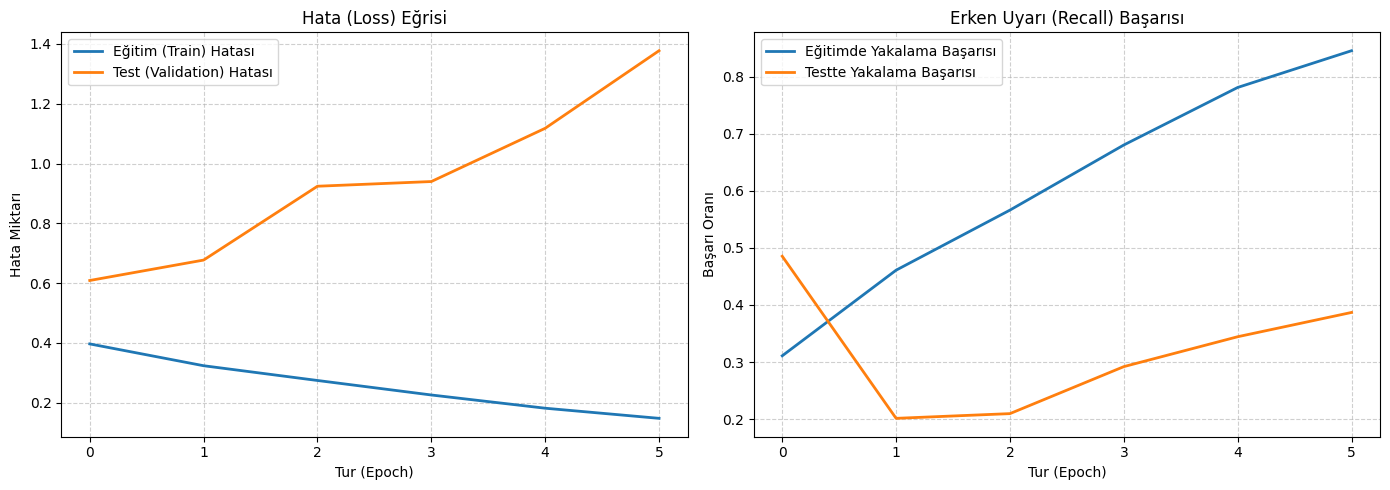

Model ilk turlarda iyi bir başlangı yapıyır hata eğrisinde istikrarlı bir şekilde azalıyor ancak iş test verisine geldiğiniz çuvallıyor. Bunun tek açıklaması overfitting var. Bunu tedevai etmemnin bir kaç yolu var. 1- ilk ayırım yaptığımız dropout kısmında yüzdesel ifadeyi arttırarak seyretmeyi azaltabiliriz. Yani modele çok hafıza kaybı yaşatarak daha topyekün öğrenmesi sağlanabilir. 2- ceza arttırımı yapabiliriz. Böylece model tembellik yapıp anomalileri bulamamazlık yapmaz. 3- Öğrenme hızını yavaşlatarak çok hızlı ezbere öğrenmeyi durdurabiliriz. Üç maddeyide uygulayacağız.